# GeoCebada — visualización rápida de los datos

Notebook introductorio para explorar los datos oficiales sin necesidad de conocer la estructura interna del proyecto.

**Objetivos**

- instalar `geocebada` en modo editable desde la propia notebook;
- cargar `BASIC`, `PRO` y el split oficial;
- revisar tamaños, columnas, missingness y rendimiento;
- visualizar relaciones con un **pairplot triangular ligero**;
- construir una vista descriptiva por parcela para el ciclo abril–octubre de 2025;
- mostrar al final el diccionario `docs/VARIABLES.md`.

> Las tablas satelitales son longitudinales: una parcela aparece muchas veces. Los puntos de una captura **no son observaciones independientes** para inferencia o validación de modelos.


## 0. Instalación

Sí: una notebook puede ejecutar `pip install -e`. La celda siguiente busca automáticamente la raíz del repositorio y hace una instalación editable del paquete.

Esto significa que, si un compañero actualiza el repositorio, **no tiene que copiar funciones ni modificar `sys.path`**. Sólo vuelve a ejecutar esta celda si cambia de entorno de Python.


In [1]:
import subprocess
import sys
from pathlib import Path


def find_repo_root(start: Path | None = None) -> Path:
    """Find the GeoCebada repository root from the current working directory."""
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists() and (candidate / "src" / "geocebada").exists():
            return candidate
    raise RuntimeError(
        "No se encontró la raíz de GeoCebada. Abre Jupyter desde dentro del repositorio."
    )


ROOT = find_repo_root()
print(f"Repositorio: {ROOT}")

subprocess.check_call(
    [sys.executable, "-m", "pip", "install", "-e", str(ROOT)]
)

print("geocebada instalado en modo editable.")


Repositorio: /home/herie/projects/GeoCebada
Obtaining file:///home/herie/projects/GeoCebada
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Checking if build backend supports build_editable: started
  Checking if build backend supports build_editable: finished with status 'done'
  Getting requirements to build editable: started
  Getting requirements to build editable: finished with status 'done'
  Preparing editable metadata (pyproject.toml): started
  Preparing editable metadata (pyproject.toml): finished with status 'done'
  Building editable for geocebada (pyproject.toml): started
  Building editable for geocebada (pyproject.toml): finished with status 'done'
  Created wheel for geocebada: filename=geocebada-0.1.0-0.editable-py3-none-any.whl size=5317 sha256=b00b98ad2e69a11d1fe4df471317fae924ff150e661c4dea73a38c1f0aa79bc9
  Stored in directory: /tmp/pip-ephem-wheel-cache-f_fu_ipp/wheels/dd/ca/70/43b85b602b5ce22203c97c71f0500c7

## 1. Importaciones y configuración

Cambia `SOURCE` entre `"BASIC"` y `"PRO"` para explorar una u otra tabla satelital.

El pairplot usa una muestra aleatoria pequeña. Los puntos se dibujan con `rasterized=True`, de modo que si después guardan la figura en PDF/SVG los miles de puntos no convierten el archivo en un vector enorme.


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

from geocebada.data import (
    attach_yield_split_metadata,
    load_basic_data,
    load_pro_data,
    load_yield_split,
)

RANDOM_SEED = 42
SOURCE = "BASIC"  # "BASIC" o "PRO"
PAIR_SAMPLE = 2_000

plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 120)


## 2. Cargar los datos oficiales


In [3]:
split = load_yield_split()
basic = load_basic_data()
pro = load_pro_data()

print(f"Split: {split.shape[0]:,} filas × {split.shape[1]:,} columnas")
print(f"BASIC: {basic.shape[0]:,} filas × {basic.shape[1]:,} columnas")
print(f"PRO:   {pro.shape[0]:,} filas × {pro.shape[1]:,} columnas")

display(split.head())


Split: 197 filas × 4 columnas
BASIC: 107,666 filas × 96 columnas
PRO:   47,804 filas × 20 columnas


,ID_POLIGONO,AREA_HA,RENDIMIENTO_T_HA,CONJUNTO
0,AGC_001,7.61,3.50,ENTRENAMIENTO
1,AGC_002,2.31,4.63,ENTRENAMIENTO
2,AGC_003,18.68,NaN,PREDICCION
3,AGC_004,8.00,3.00,ENTRENAMIENTO
4,AGC_005,2.27,5.16,ENTRENAMIENTO


### Resumen rápido del split


In [4]:
summary = (
    split.groupby("CONJUNTO", dropna=False)
    .agg(
        parcelas=("ID_POLIGONO", "nunique"),
        area_total_ha=("AREA_HA", "sum"),
        rendimiento_observado=("RENDIMIENTO_T_HA", "count"),
    )
)
display(summary)


,parcelas,area_total_ha,rendimiento_observado
CONJUNTO,,,
ENTRENAMIENTO,138,907.48,138
PREDICCION,59,393.57,0


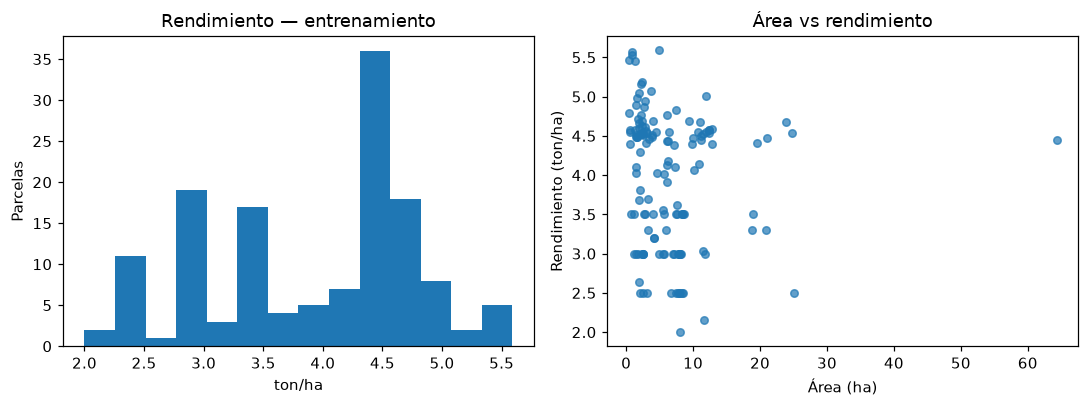

In [5]:
train = split.loc[split["CONJUNTO"].eq("ENTRENAMIENTO")].copy()

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))

axes[0].hist(train["RENDIMIENTO_T_HA"].dropna(), bins=14)
axes[0].set_title("Rendimiento — entrenamiento")
axes[0].set_xlabel("ton/ha")
axes[0].set_ylabel("Parcelas")

axes[1].scatter(
    train["AREA_HA"],
    train["RENDIMIENTO_T_HA"],
    s=24,
    alpha=0.7,
)
axes[1].set_title("Área vs rendimiento")
axes[1].set_xlabel("Área (ha)")
axes[1].set_ylabel("Rendimiento (ton/ha)")

fig.tight_layout()
plt.show()


## 3. Elegir BASIC o PRO

Se adjuntan `AREA_HA`, `CONJUNTO` y `RENDIMIENTO_T_HA` por `ID_POLIGONO`. Para las parcelas de `PREDICCION`, el rendimiento continúa vacío.


In [6]:
if SOURCE.upper() == "BASIC":
    satellite = attach_yield_split_metadata(basic)
    default_pair_columns = [
        "ndvi_promedio",
        "evi_promedio",
        "lai_promedio",
        "ndwi_promedio",
        "msi_promedio",
        "nddi_promedio",
    ]
elif SOURCE.upper() == "PRO":
    satellite = attach_yield_split_metadata(pro)
    default_pair_columns = [
        "ndvi_promedio",
        "evi_promedio",
        "lai_promedio",
        "msavi_promedio",
    ]
else:
    raise ValueError("SOURCE debe ser 'BASIC' o 'PRO'.")

print(f"{SOURCE.upper()}: {satellite.shape[0]:,} filas × {satellite.shape[1]:,} columnas")
print(f"Parcelas únicas: {satellite['ID_POLIGONO'].nunique():,}")
print("Sensores:", satellite["sensor"].dropna().unique().tolist())

display(satellite.head())


BASIC: 107,666 filas × 99 columnas
Parcelas únicas: 197
Sensores: ['Landsat', 'Sentinel-2']


,ID_POLIGONO,fecha_captura,sensor,ndvi_promedio,ndvi_std,ndvi_max,ndvi_min,evi_promedio,evi_std,evi_max,evi_min,crc_promedio,crc_std,crc_max,crc_min,mcrc_promedio,mcrc_std,mcrc_max,mcrc_min,ndsvi_promedio,ndsvi_std,ndsvi_max,ndsvi_min,srndi_promedio,srndi_std,srndi_max,srndi_min,mra_promedio,mra_std,mra_max,mra_min,lai_promedio,lai_std,lai_max,lai_min,fapar_promedio,fapar_std,fapar_max,fapar_min,savi_promedio,savi_std,savi_max,savi_min,vi6t_promedio,vi6t_std,vi6t_max,vi6t_min,ndti_promedio,ndti_std,ndti_max,ndti_min,sti_promedio,sti_std,sti_max,sti_min,ndwi_promedio,ndwi_std,ndwi_max,ndwi_min,endwi_promedio,endwi_std,endwi_max,endwi_min,msi_promedio,msi_std,msi_max,msi_min,emsi_promedio,emsi_std,emsi_max,emsi_min,dswi2_promedio,dswi2_std,dswi2_max,dswi2_min,dswi3_promedio,dswi3_std,dswi3_max,dswi3_min,dswi4_promedio,dswi4_std,dswi4_max,dswi4_min,dswi5_promedio,dswi5_std,dswi5_max,dswi5_min,nddi_promedio,nddi_std,nddi_max,nddi_min,enddi_promedio,enddi_std,enddi_max,enddi_min,porcentaje_nubosidad,AREA_HA,RENDIMIENTO_T_HA,CONJUNTO
0,AGC_011,20/04/2022,Landsat,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.613,0.018,-0.561,-0.678,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,7.17,NaN,PREDICCION
1,AGC_011,16/03/2024,Landsat,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.626,0.014,-0.590,-0.679,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,7.17,NaN,PREDICCION
2,AGC_011,15/03/2024,Landsat,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.635,0.014,-0.600,-0.686,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,7.17,NaN,PREDICCION
3,AGC_011,26/08/2025,Landsat,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.635,0.014,-0.578,-0.674,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,7.17,NaN,PREDICCION
4,AGC_011,10/03/2025,Landsat,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.644,0.015,-0.590,-0.689,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,7.17,NaN,PREDICCION


### Missingness de las variables seleccionadas


In [7]:
missing = (
    satellite[default_pair_columns]
    .isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .rename("% missing")
    .to_frame()
)
display(missing)


,% missing
ndvi_promedio,58.318318
evi_promedio,58.318318
lai_promedio,58.318318
ndwi_promedio,58.318318
msi_promedio,58.318318
nddi_promedio,58.318318


## 4. Pairplot triangular ligero

Este pairplot es deliberadamente sencillo:

- sólo muestra la diagonal y el triángulo inferior;
- usa como máximo `PAIR_SAMPLE` filas completas;
- los puntos están rasterizados;
- no usa las 100 mil observaciones si no es necesario.

En esta primera figura cada punto es una **captura satelital**, no una parcela independiente.


In [14]:
def triangular_pairplot(
    frame: pd.DataFrame,
    columns: list[str],
    *,
    sample: int = 2_000,
    random_state: int = 42,
    bins: int = 24,
) -> tuple[plt.Figure, np.ndarray]:
    """Draw a lightweight lower-triangular pairplot with rasterized scatter points."""
    data = frame[columns].dropna()

    if data.empty:
        raise ValueError("No hay filas completas para las columnas seleccionadas.")

    if len(data) > sample:
        data = data.sample(sample, random_state=random_state)

    n = len(columns)
    fig, axes = plt.subplots(
        n,
        n,
        figsize=(1.8 * n, 1.8 * n),
        squeeze=False,
    )

    for row, y_col in enumerate(columns):
        for col, x_col in enumerate(columns):
            ax = axes[row, col]

            if col > row:
                ax.axis("off")
                continue

            if row == col:
                ax.hist(data[x_col], bins=bins)
            else:
                ax.scatter(
                    data[x_col],
                    data[y_col],
                    s=7,
                    alpha=0.22,
                    linewidths=0,
                    rasterized=True,
                )

            if row == n - 1:
                ax.set_xlabel(x_col, fontsize=8, rotation=25, ha="right")
            else:
                ax.set_xticklabels([])

            if col == 0:
                ax.set_ylabel(y_col, fontsize=8)
            else:
                ax.set_yticklabels([])

            ax.tick_params(labelsize=7)

    fig.suptitle(
        f"Pairplot triangular — {len(data):,} observaciones muestreadas",
        y=1.01,
    )
    fig.tight_layout()
    return fig, axes


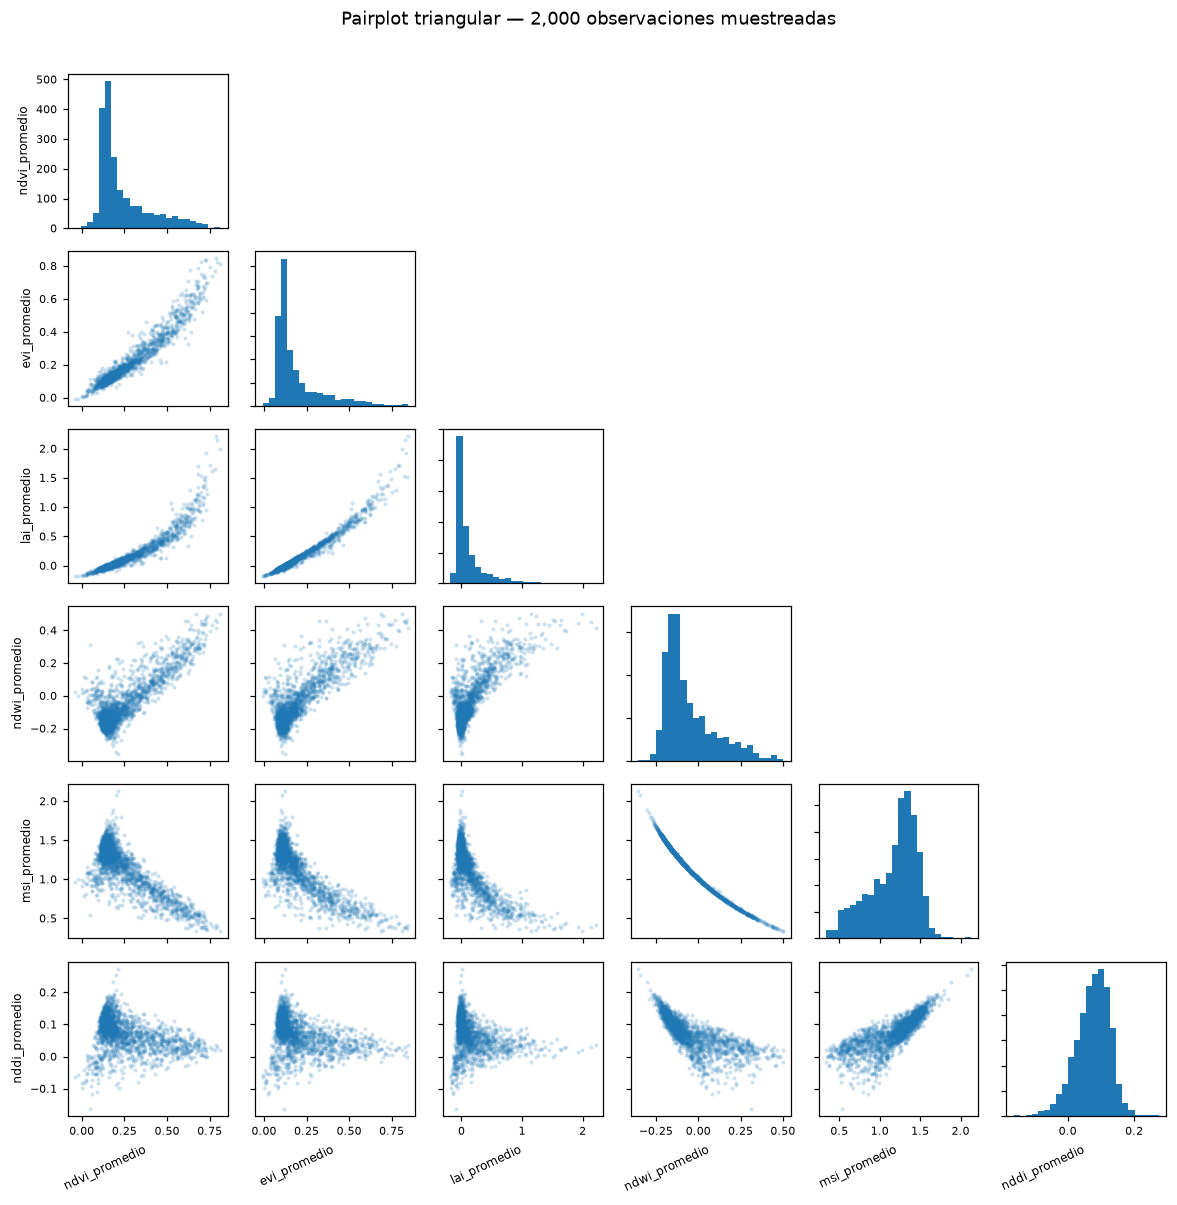

In [9]:
pair_columns = [column for column in default_pair_columns if column in satellite.columns]

fig, _ = triangular_pairplot(
    satellite,
    pair_columns,
    sample=PAIR_SAMPLE,
    random_state=RANDOM_SEED,
)
plt.show()


## 5. Vista descriptiva por parcela para abril–octubre de 2025

El target oficial corresponde al ciclo **abril–octubre de 2025**. Para una visualización más cercana a la unidad final de predicción, aquí reducimos temporalmente las observaciones satelitales de ese periodo a **una fila por parcela** usando la mediana.

Esto es sólo una **vista descriptiva**. No constituye todavía el feature engineering final: faltan decisiones de nubosidad, sensor, ventanas temporales, agregaciones y validación.


In [10]:
satellite_cycle = satellite.copy()
satellite_cycle["fecha_captura"] = pd.to_datetime(
    satellite_cycle["fecha_captura"],
    errors="coerce",
)

cycle_mask = satellite_cycle["fecha_captura"].between(
    "2025-04-01",
    "2025-10-31",
)

cycle = satellite_cycle.loc[cycle_mask].copy()

parcel_satellite = (
    cycle.groupby("ID_POLIGONO", as_index=False)[pair_columns]
    .median(numeric_only=True)
)

parcel_view = split.merge(
    parcel_satellite,
    on="ID_POLIGONO",
    how="left",
    validate="one_to_one",
)

print(f"Parcelas en la vista: {len(parcel_view):,}")
display(parcel_view.head())


Parcelas en la vista: 197


/tmp/ipykernel_11557/2818450643.py:2: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  satellite_cycle["fecha_captura"] = pd.to_datetime(


,ID_POLIGONO,AREA_HA,RENDIMIENTO_T_HA,CONJUNTO,ndvi_promedio,evi_promedio,lai_promedio,ndwi_promedio,msi_promedio,nddi_promedio
0,AGC_001,7.61,3.50,ENTRENAMIENTO,0.2485,0.2015,0.1130,0.0145,0.9820,0.0540
1,AGC_002,2.31,4.63,ENTRENAMIENTO,0.4380,0.3175,0.3295,0.1405,0.7625,0.0625
2,AGC_003,18.68,NaN,PREDICCION,0.3820,0.2220,0.1520,0.0500,0.9180,0.0490
3,AGC_004,8.00,3.00,ENTRENAMIENTO,0.3370,0.2610,0.2070,-0.0110,1.0370,0.0820
4,AGC_005,2.27,5.16,ENTRENAMIENTO,0.3170,0.2260,0.1840,-0.1130,1.2770,0.1130


### Pairplot a nivel de parcela

Ahora cada punto sí corresponde a una parcela. Para incluir `RENDIMIENTO_T_HA`, sólo se muestran parcelas de entrenamiento.


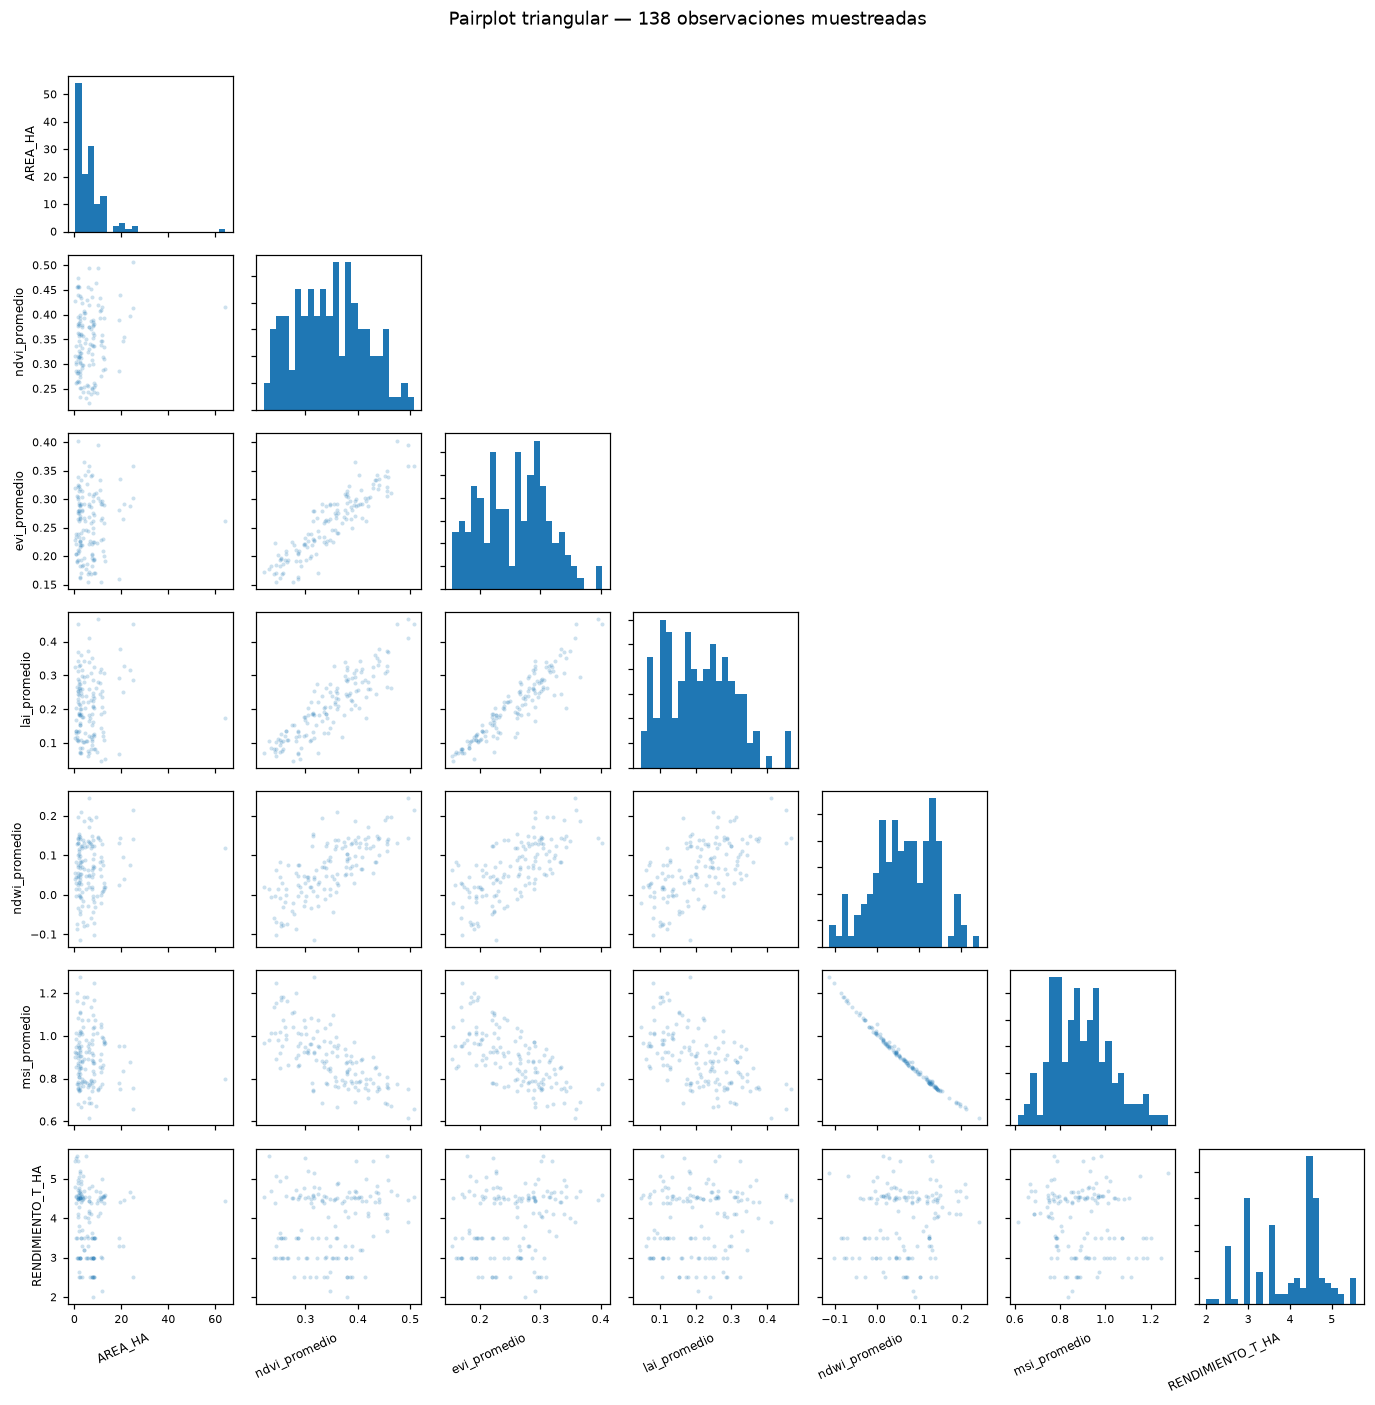

In [11]:
parcel_train = parcel_view.loc[
    parcel_view["CONJUNTO"].eq("ENTRENAMIENTO")
].copy()

parcel_pair_columns = [
    "AREA_HA",
    *pair_columns[:5],
    "RENDIMIENTO_T_HA",
]
parcel_pair_columns = [
    column for column in parcel_pair_columns if column in parcel_train.columns
]

fig, _ = triangular_pairplot(
    parcel_train,
    parcel_pair_columns,
    sample=len(parcel_train),
    random_state=RANDOM_SEED,
)
plt.show()


## 6. Correlaciones descriptivas por parcela

La matriz siguiente es exploratoria. Correlación no implica causalidad y, con parcelas georreferenciadas, la independencia espacial tampoco debe darse por sentada.


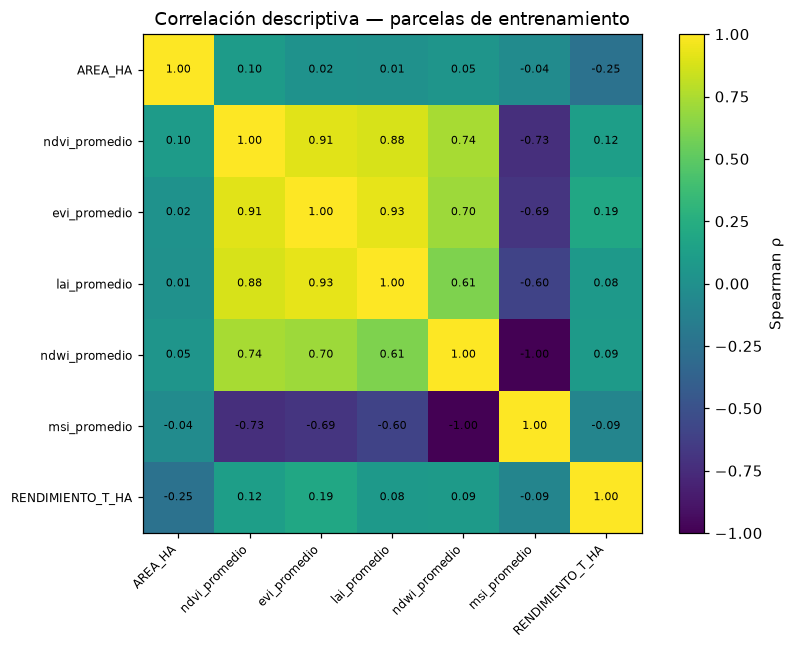

In [12]:
corr = parcel_train[parcel_pair_columns].corr(method="spearman")

fig, ax = plt.subplots(figsize=(8, 6))
image = ax.imshow(corr, vmin=-1, vmax=1)

ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(corr.index)))
ax.set_yticklabels(corr.index, fontsize=8)

for row in range(len(corr.index)):
    for col in range(len(corr.columns)):
        ax.text(
            col,
            row,
            f"{corr.iloc[row, col]:.2f}",
            ha="center",
            va="center",
            fontsize=7,
        )

fig.colorbar(image, ax=ax, label="Spearman ρ")
ax.set_title("Correlación descriptiva — parcelas de entrenamiento")
fig.tight_layout()
plt.show()


## 7. Diccionario completo de variables

La siguiente celda muestra directamente `docs/VARIABLES.md`.

No copiamos el contenido dentro de la notebook: así el notebook siempre muestra la versión actual del diccionario cuando el equipo actualiza la documentación.


In [13]:
variables_path = ROOT / "docs" / "VARIABLES.md"
display(Markdown(variables_path.read_text(encoding="utf-8")))


# Diccionario de variables — GeoCebada

Este documento resume las variables oficiales entregadas para el Reto AgroCebada FIRA 2026 y cómo deben interpretarse dentro de GeoCebada.

Las descripciones se basan en los archivos oficiales de referencia:

- `docs/reference/Descripcion_general_variables_DataSet.docx`
- `docs/reference/Diccionario_de_indices_satelitales.docx`
- los esquemas observados directamente en los CSV de `data/source/tabular/`
- los metadatos entregados con los rasters climáticos y topográficos.

> **Regla importante.** El diccionario oficial de índices es conceptual. Para índices que tengan varias formulaciones publicadas o una implementación específica del proveedor, **no debe suponerse una fórmula distinta de la utilizada por la fuente de datos**. Este documento explica qué representa cada variable, pero no inventa fórmulas no entregadas por FIRA.

## 1. Unidad de análisis y target

La unidad final de predicción es una parcela agrícola identificada por `ID_POLIGONO`.

El archivo oficial de target/split es:

`data/source/tabular/ID_area_rendimiento_70_30_Reto_AgroCebada.csv`

| Variable | Tipo conceptual | Significado |
|---|---|---|
| `ID_POLIGONO` | Identificador | Identificador único de parcela, desde `AGC_001` hasta `AGC_197`. Es la llave canónica para relacionar tablas, geometrías, rasters y features derivados. |
| `AREA_HA` | Geométrica | Área de la parcela en hectáreas. Está disponible para las 197 parcelas. |
| `RENDIMIENTO_T_HA` | Target | Rendimiento agrícola de cebada en toneladas por hectárea. Está observado para las 138 parcelas de entrenamiento y oculto para las 59 de predicción. |
| `CONJUNTO` | Split | Define si la parcela pertenece a `ENTRENAMIENTO` o `PREDICCION`. |

### Ciclo agrícola del target

La documentación oficial de descripción general establece que `RENDIMIENTO_T_HA` corresponde al **ciclo de producción abril–octubre de 2025**.

Esto resuelve el año/ciclo representado por el target, pero no define por sí solo el instante exacto en el que una predicción operativa debe considerarse disponible. Para modelos de pronóstico antes de cosecha todavía debe definirse una ventana temporal que no incorpore información posterior al horizonte de predicción.

## 2. Cómo leer las columnas satelitales

Las tablas BASIC y PRO son **longitudinales**: una parcela aparece repetidamente para distintas fechas de captura y, en BASIC, para distintos sensores.

Las columnas de índices siguen normalmente este patrón:

```text
<indice>_<estadistico>
```

Cada estadístico describe la distribución espacial del índice dentro de la parcela en una fecha determinada.

| Sufijo | Significado |
|---|---|
| `_promedio` | Valor medio del índice dentro de la parcela para esa observación. |
| `_std` | Desviación estándar espacial dentro de la parcela; mide heterogeneidad interna. |
| `_max` | Valor máximo observado dentro de la parcela. |
| `_min` | Valor mínimo observado dentro de la parcela. |

Por ejemplo, una observación puede contener simultáneamente:

```text
ndvi_promedio
ndvi_std
ndvi_max
ndvi_min
```

Estos cuatro campos no son cuatro índices diferentes; son cuatro resúmenes espaciales del mismo índice.

## 3. Variables comunes de BASIC y PRO

| Variable | Significado |
|---|---|
| `ID_POLIGONO` | Parcela a la que pertenece la observación. |
| `fecha_captura` | Fecha de adquisición/captura de la observación satelital. |
| `sensor` | Sensor/plataforma de origen de la observación. Debe conservarse porque mediciones con el mismo nombre de índice no son necesariamente equivalentes entre sensores. |
| `porcentaje_nubosidad` | Variable de calidad que representa el porcentaje de nubosidad asociado con la observación. Puede utilizarse para definir criterios de filtrado, calidad y tratamiento de faltantes. |

## 4. Dataset BASIC

Archivo:

`data/source/tabular/Conjunto_datos_BASICO_AgroCebada2026.csv`

Esquema auditado:

- 107,666 observaciones;
- 96 columnas;
- 197 parcelas;
- observaciones de **Sentinel-2 y Landsat**;
- cobertura temporal **2022–2025**;
- los registros de sensores distintos permanecen separados;
- VI6T está asociado con las observaciones Landsat; la mayor parte de los otros índices proviene de Sentinel-2.

BASIC contiene 23 familias de índices. Cada familia aparece con `_promedio`, `_std`, `_max` y `_min`, lo que produce 92 columnas numéricas de índices, además de `ID_POLIGONO`, `fecha_captura`, `sensor` y `porcentaje_nubosidad`.

### 4.1 Índices BASIC

| Prefijo | Nombre / categoría oficial | Qué representa | Columnas del CSV |
|---|---|---|---|
| `ndvi` | Normalized Difference Vegetation Index (NDVI) | Indicador general de presencia, vigor y actividad de vegetación verde. | `ndvi_promedio`, `ndvi_std`, `ndvi_max`, `ndvi_min` |
| `evi` | Enhanced Vegetation Index (EVI) | Índice de vigor vegetal diseñado para reducir parte de la influencia del suelo y de efectos atmosféricos. | `evi_promedio`, `evi_std`, `evi_max`, `evi_min` |
| `crc` | Crop Residue Cover Index (CRC) | Respuesta espectral asociada con cobertura de residuos de cultivo sobre la superficie. | `crc_promedio`, `crc_std`, `crc_max`, `crc_min` |
| `mcrc` | Modified Crop Residue Cover (MCRC) | Variante modificada de índices orientados a detectar residuos de cultivo. | `mcrc_promedio`, `mcrc_std`, `mcrc_max`, `mcrc_min` |
| `ndsvi` | Normalized Difference Senescent Vegetation Index (NDSVI) | Índice sensible a vegetación senescente y material vegetal no fotosintético. | `ndsvi_promedio`, `ndsvi_std`, `ndsvi_max`, `ndsvi_min` |
| `srndi` | Shortwave Red Normalized Difference Index (SRNDI) | Contrasta información del infrarrojo de onda corta con la región roja del espectro. | `srndi_promedio`, `srndi_std`, `srndi_max`, `srndi_min` |
| `mra` | MRA, nomenclatura del proveedor | Variable espectral entregada bajo la abreviatura MRA. La documentación no proporciona una expansión o fórmula adicional; no debe inventarse. | `mra_promedio`, `mra_std`, `mra_max`, `mra_min` |
| `lai` | Leaf Area Index (LAI) | Variable biofísica que representa la cantidad de superficie foliar respecto de la superficie del terreno. | `lai_promedio`, `lai_std`, `lai_max`, `lai_min` |
| `fapar` | Fraction of Absorbed Photosynthetically Active Radiation (FAPAR) | Fracción de la radiación fotosintéticamente activa absorbida por la vegetación. | `fapar_promedio`, `fapar_std`, `fapar_max`, `fapar_min` |
| `savi` | Soil-Adjusted Vegetation Index (SAVI) | Índice de vegetación que reduce la influencia del brillo del suelo. | `savi_promedio`, `savi_std`, `savi_max`, `savi_min` |
| `vi6t` | VI6T | Índice espectral-térmico de Landsat. Combina información de una banda espectral con información térmica de la superficie y puede aportar señal complementaria sobre condiciones espectrales y térmicas. | `vi6t_promedio`, `vi6t_std`, `vi6t_max`, `vi6t_min` |
| `ndti` | Normalized Difference Tillage Index (NDTI) | Índice basado en infrarrojo de onda corta para caracterizar suelo, residuos y condiciones de labranza. | `ndti_promedio`, `ndti_std`, `ndti_max`, `ndti_min` |
| `sti` | Simple Tillage Index (STI) | Relación espectral utilizada para caracterizar residuos y condiciones de labranza. | `sti_promedio`, `sti_std`, `sti_max`, `sti_min` |
| `ndwi` | Normalized Difference Water Index (NDWI) | Índice relacionado con agua o humedad a partir del contraste entre bandas espectrales. | `ndwi_promedio`, `ndwi_std`, `ndwi_max`, `ndwi_min` |
| `endwi` | Enhanced Normalized Difference Water Index (ENDWI) | Variante mejorada de un índice normalizado de agua/humedad. | `endwi_promedio`, `endwi_std`, `endwi_max`, `endwi_min` |
| `msi` | Moisture Stress Index (MSI) | Índice sensible al contenido de agua de la vegetación y al estrés hídrico. | `msi_promedio`, `msi_std`, `msi_max`, `msi_min` |
| `emsi` | Enhanced Moisture Stress Index (EMSI) | Variante orientada a ampliar la sensibilidad a cambios de humedad o estrés de la vegetación. | `emsi_promedio`, `emsi_std`, `emsi_max`, `emsi_min` |
| `dswi2` | Disease-Water Stress Index 2 (DSWI2) | Índice espectral desarrollado para detectar cambios relacionados con estrés hídrico y condición vegetal. | `dswi2_promedio`, `dswi2_std`, `dswi2_max`, `dswi2_min` |
| `dswi3` | Disease-Water Stress Index 3 (DSWI3) | Variante de la familia Disease-Water Stress Index con una combinación distinta de bandas. | `dswi3_promedio`, `dswi3_std`, `dswi3_max`, `dswi3_min` |
| `dswi4` | Disease-Water Stress Index 4 (DSWI4) | Índice de la misma familia que utiliza un contraste espectral diferente. | `dswi4_promedio`, `dswi4_std`, `dswi4_max`, `dswi4_min` |
| `dswi5` | Disease-Water Stress Index 5 (DSWI5) | Índice multibanda orientado a caracterizar condición vegetal y estrés hídrico. | `dswi5_promedio`, `dswi5_std`, `dswi5_max`, `dswi5_min` |
| `nddi` | Normalized Difference Drought Index (NDDI) | Integra información de vegetación y humedad para caracterizar condiciones de sequedad. | `nddi_promedio`, `nddi_std`, `nddi_max`, `nddi_min` |
| `enddi` | Enhanced Normalized Difference Drought Index (ENDDI) | Variante mejorada de un índice de sequedad que incorpora una señal hídrica complementaria. | `enddi_promedio`, `enddi_std`, `enddi_max`, `enddi_min` |

### 4.2 Missingness en BASIC

La tabla BASIC presenta faltantes relevantes y éstos no deben interpretarse automáticamente como cero. En la auditoría inicial, VI6T es una de las familias con mayor cantidad de valores ausentes; también existen faltantes sustanciales en otras familias como FAPAR y NDVI.

La combinación de `sensor`, `fecha_captura`, `porcentaje_nubosidad` y disponibilidad específica de cada índice debe considerarse al construir features.

## 5. Dataset PRO

Archivo:

`data/source/tabular/Conjunto_datos_PRO_AgroCebada.csv`

Esquema auditado:

- 47,804 observaciones;
- 20 columnas;
- 197 parcelas;
- fuente **Planet**;
- cobertura **2025**.

PRO contiene cuatro familias de índices, cada una con `_promedio`, `_std`, `_max` y `_min`.

| Prefijo | Nombre / categoría oficial | Qué representa | Columnas del CSV |
|---|---|---|---|
| `ndvi` | Normalized Difference Vegetation Index (NDVI) | Indicador general de vigor y presencia de vegetación verde. | `ndvi_promedio`, `ndvi_std`, `ndvi_max`, `ndvi_min` |
| `evi` | Enhanced Vegetation Index (EVI) | Indicador de vigor vegetal con ajustes para reducir parte de los efectos del fondo y la atmósfera. | `evi_promedio`, `evi_std`, `evi_max`, `evi_min` |
| `lai` | Leaf Area Index (LAI) | Variable biofísica relacionada con la superficie foliar del dosel. | `lai_promedio`, `lai_std`, `lai_max`, `lai_min` |
| `msavi` | Modified Soil-Adjusted Vegetation Index (MSAVI) | Índice de vegetación diseñado para reducir de forma adaptativa la influencia del suelo. | `msavi_promedio`, `msavi_std`, `msavi_max`, `msavi_min` |

### BASIC y PRO no son intercambiables

Aunque BASIC y PRO compartan nombres como NDVI, EVI y LAI, la documentación oficial advierte que provienen de fuentes distintas y **no deben fusionarse automáticamente como si fueran mediciones equivalentes**.

Las diferencias entre sensores pueden incluir resolución espacial, respuesta espectral, frecuencia de observación y procesamiento. Por ello debe conservarse `sensor` y documentarse cualquier armonización posterior.

## 6. Variables climáticas

Los datos climáticos no llegan como columnas tabulares por parcela. Se entregan como rasters mensuales y deben extraerse espacialmente para cada polígono mediante un procedimiento reproducible, por ejemplo zonal statistics.

### 6.1 Precipitación

| Propiedad | Valor |
|---|---|
| Variable | Precipitación mensual acumulada |
| Fuente | CHIRPS |
| Cobertura | enero 2022–diciembre 2025 |
| Archivo | `PREC_AAAA_MM.tif` |
| Unidad entregada | mm/mes |
| Interpretación | Suma de la precipitación registrada durante el mes; permite caracterizar disponibilidad y distribución temporal de lluvia. |
| CRS entregado | EPSG:4326 |
| Resolución aproximada | 0.05° × 0.05° (~5 km) |

Features derivados posibles, una vez fijado el horizonte temporal, incluyen acumulados por etapa del cultivo, número de meses secos, anomalías y distribución intraestacional. Estos campos serían **features de GeoCebada**, no variables originales de FIRA.

### 6.2 Temperatura mínima

| Propiedad | Valor |
|---|---|
| Variable | Temperatura mínima mensual |
| Fuente | CHIRTS-ERA5 |
| Cobertura | enero 2022–diciembre 2025 |
| Archivo | `Tmin_AAAA_MM.tif` |
| Unidad | °C |
| Interpretación | Promedio mensual de la temperatura mínima; caracteriza las condiciones térmicas más bajas del periodo. |
| CRS | EPSG:4326 |
| Resolución aproximada | 0.05° × 0.05° (~5 km) |

### 6.3 Temperatura máxima

| Propiedad | Valor |
|---|---|
| Variable | Temperatura máxima mensual |
| Fuente | CHIRTS-ERA5 |
| Cobertura | enero 2022–diciembre 2025 |
| Archivo | `Tmax_AAAA_MM.tif` |
| Unidad | °C |
| Interpretación | Promedio mensual de la temperatura máxima; permite caracterizar diferencias térmicas entre meses y zonas. |
| CRS | EPSG:4326 |
| Resolución aproximada | 0.05° × 0.05° (~5 km) |

La documentación oficial menciona explícitamente que pueden construirse indicadores adicionales como temperatura media, amplitud térmica y acumulados por periodos específicos. Esas transformaciones deben documentarse y respetar el horizonte de predicción.

## 7. Variables topográficas

También son rasters y no columnas del CSV original.

| Variable | Archivo entregado | Qué representa | Unidad / escala operativa |
|---|---|---|---|
| Elevación | `Elevacion_INEGI_CEM4_120m.tif` | Altitud del terreno; ayuda a caracterizar diferencias ambientales y topográficas entre parcelas. | metros sobre el nivel del mar; raster entregado a 120 m |
| Pendiente | `Pendiente_INEGI_CEM4_120m_grados.tif` | Inclinación del terreno; describe condiciones topográficas que pueden relacionarse con drenaje, exposición y microclima. | grados; raster entregado a 120 m |

Los productos entregados usan EPSG:6372. Deben reproyectarse de forma explícita antes de combinarlos con capas en otro CRS.

## 8. Geometría de parcela

La capa vectorial oficial contiene las 197 geometrías. La documentación de referencia indica que incluye identificador, área y `CONJUNTO`.

La geometría permite crear variables derivadas como centroides, perímetro, compactación, vecindad o agregados raster, pero esas variables no deben confundirse con columnas originales del dataset.

El CRS de la capa de parcelas debe verificarse directamente desde el archivo antes de calcular áreas, distancias o realizar overlays.

## 9. Qué significa una fila

### Archivo de target/split

Una fila representa **una parcela**:

```text
ID_POLIGONO → una parcela → un rendimiento objetivo
```

### BASIC y PRO

Una fila representa una **observación satelital de una parcela en una fecha y sensor**:

```text
ID_POLIGONO + fecha_captura + sensor → una observación
```

Por ello, las 107,666 filas BASIC y las 47,804 filas PRO **no son muestras independientes de rendimiento**. Las parcelas se repiten muchas veces.

En validación supervisada nunca debe hacerse un split aleatorio fila-a-fila que permita que observaciones de una misma parcela aparezcan simultáneamente en train y validation.

## 10. Cómo pasan las variables longitudinales al modelo

El target existe una vez por parcela, mientras que los índices satelitales y el clima tienen múltiples observaciones temporales. El modelado final requiere transformar las series a features por parcela o usar un método temporal que respete la agrupación por parcela.

Ejemplos de features derivados potenciales:

```text
ndvi_mean_apr_jun
ndvi_peak
ndvi_date_peak
ndvi_auc
ndvi_slope
ndvi_std_temporal
precip_sum_apr_jun
tmin_mean_apr_jun
tmax_mean_apr_jun
thermal_range_mean
elevation_mean
slope_mean
```

Estos nombres son ejemplos metodológicos de GeoCebada; **no son columnas oficiales entregadas por FIRA**.

## 11. Reglas de interpretación

1. No existen umbrales universales para los índices aplicables a todas las parcelas, fechas y etapas fenológicas.
2. La evolución temporal del cultivo importa: un valor aislado puede significar cosas distintas según la etapa fenológica.
3. Conservar siempre `sensor` durante auditoría, exploración y construcción inicial de features.
4. No asumir que NDVI/EVI/LAI de BASIC y PRO son directamente equivalentes.
5. `porcentaje_nubosidad` es una señal de calidad y puede explicar parte del missingness.
6. No tratar valores faltantes como cero sin justificación.
7. No inventar fórmulas para MRA, VI6T u otros índices cuya implementación exacta no haya sido proporcionada.
8. El target corresponde al ciclo abril–octubre de 2025, pero el corte temporal exacto para una predicción pre-cosecha debe definirse explícitamente antes de congelar features.
9. Las transformaciones derivadas deben registrarse en código bajo `src/geocebada/features/` cuando dejen de ser exploratorias.

## 12. Resumen de fuentes de información

| Componente | Fuente | Cobertura | Papel en GeoCebada |
|---|---|---|---|
| Target / split | Datos del reto | ciclo abril–octubre 2025 | Target, área y partición train/prediction |
| BASIC | Sentinel-2 + Landsat | 2022–2025 | Series temporales de índices satelitales |
| PRO | Planet | 2025 | Series temporales de NDVI, EVI, LAI y MSAVI |
| Precipitación | CHIRPS | 2022–2025 | Disponibilidad y distribución temporal de lluvia |
| Tmin/Tmax | CHIRTS-ERA5 | 2022–2025 | Condiciones térmicas |
| Elevación | INEGI CEM | estática | Contexto topográfico |
| Pendiente | derivada de CEM | estática | Inclinación del terreno |
| Geometrías | parcelas del reto | 197 parcelas | Integración espacial, mapas y extracción raster |

## 13. Archivos relacionados

Para esquema físico y missingness observado:

`reports/data_schema_official.md`

Para estructura general del dataset:

`data/README.md`

Para localizar funciones de carga/procesamiento:

`docs/FUNCTION_INDEX.md`


## Qué sigue

Esta notebook es para **entender rápidamente los datos**, no para entrenar el modelo final.

Las siguientes notebooks pueden separar responsabilidades:

1. auditoría temporal y de nubosidad;
2. feature engineering por parcela;
3. validación espacial/agrupada;
4. baselines y comparación de modelos;
5. explicabilidad y predicciones finales.
